# EDA: ¿es el iPhone Duo un móvil o un iPad mini plegable?

En este análisis exploraré las características físicas y las pantallas del iPhone Duo para determinar si se aproxima más a un teléfono móvil convencional o a una tableta compacta.

Utilizaré como referencias dos móviles tradicionales, dos plegables rivales y el iPad mini. Analizaré variables como el peso, las dimensiones, el grosor, el precio y la superficie aproximada de las pantallas.

Los datos originales fueron recopilados previamente a partir de fuentes oficiales de Apple, Samsung y Google.

In [1]:
# importo path para gestionar las rutas de archivos y carpetas
from pathlib import Path

# importo matplotlib para personalizar y guardar los gráficos del análisis
import matplotlib.pyplot as plt

# importo numpy para realizar cálculos matemáticos
import numpy as np

# importo pandas para cargar, limpiar y analizar los datos
import pandas as pd

# importo seaborn para crear gráficos estadísticos de forma sencilla
import seaborn as sns

# configuro pandas para mostrar todas las columnas de los dataframes
pd.set_option("display.max_columns", None)

# configuro pandas para mostrar los números con dos decimales
# sin modificar la precisión real de los datos
pd.set_option("display.float_format", "{:.2f}".format)

# aplico un estilo visual limpio y consistente a todos los gráficos
sns.set_theme(style="whitegrid")

## 1. Carga de los datos

Comenzaré cargando las tablas de dispositivos y pantallas recopiladas previamente. Los archivos originales se encuentran en la carpeta `data/raw` y permanecerán sin modificaciones durante el análisis.

Trabajaré con copias independientes para poder limpiar, transformar y enriquecer los datos sin alterar su versión original.

In [2]:
# guardo la ruta de la carpeta desde la que ejecuto el notebook
ruta_proyecto = Path.cwd()

# construyo las rutas de las carpetas utilizadas en el análisis
ruta_datos_raw = ruta_proyecto / "data" / "raw"
ruta_datos_processed = ruta_proyecto / "data" / "processed"
ruta_imagenes = ruta_proyecto / "img"

# construyo las rutas de los archivos originales
archivo_dispositivos_raw = ruta_datos_raw / "dispositivos.csv"
archivo_pantallas_raw = ruta_datos_raw / "pantallas.csv"

# compruebo que los archivos necesarios existen antes de cargarlos
print(f"archivo de dispositivos encontrado: {archivo_dispositivos_raw.exists()}")
print(f"archivo de pantallas encontrado: {archivo_pantallas_raw.exists()}")

# detengo la ejecución con un mensaje claro si falta algún archivo
assert archivo_dispositivos_raw.exists(), "no encuentro el archivo dispositivos.csv"
assert archivo_pantallas_raw.exists(), "no encuentro el archivo pantallas.csv"

archivo de dispositivos encontrado: True
archivo de pantallas encontrado: True


In [3]:
# cargo los archivos originales desde la carpeta data/raw
df_dispositivos_raw = pd.read_csv(
    archivo_dispositivos_raw,
    encoding="utf-8"
)

df_pantallas_raw = pd.read_csv(
    archivo_pantallas_raw,
    encoding="utf-8"
)

# creo copias de trabajo para conservar intactos los datos originales
df_dispositivos = df_dispositivos_raw.copy()
df_pantallas = df_pantallas_raw.copy()

# muestro las dimensiones para comprobar el número de filas y columnas
print(
    f"dispositivos: {df_dispositivos.shape[0]} filas "
    f"y {df_dispositivos.shape[1]} columnas"
)

print(
    f"pantallas: {df_pantallas.shape[0]} filas "
    f"y {df_pantallas.shape[1]} columnas"
)

dispositivos: 6 filas y 14 columnas
pantallas: 9 filas y 9 columnas


### 1.1. Inspección inicial

Antes de transformar los datos revisaré el contenido completo de las dos tablas. Esta inspección permitirá detectar posibles errores de escritura, categorías inconsistentes o valores que no resulten plausibles.

La tabla de dispositivos contiene una fila por modelo, mientras que la tabla de pantallas puede contener varias filas por dispositivo cuando este dispone de una pantalla interior y otra exterior.

In [4]:
# muestro todos los dispositivos para revisar sus características
print("tabla de dispositivos:")
display(df_dispositivos)

# separo visualmente las dos tablas
print("\ntabla de pantallas:")

# muestro todas las pantallas para revisar sus características
display(df_pantallas)

tabla de dispositivos:


,fabricante,modelo,categoria,precio_usd,almacenamiento_gb,peso_g,alto_cerrado_mm,ancho_cerrado_mm,grosor_cerrado_mm,alto_abierto_mm,ancho_abierto_mm,grosor_abierto_mm,conectividad,fuente
0,Apple,iPhone Duo,plegable,1999.00,256,254,117.80,84.10,11.30,117.80,164.60,5.20,5G,https://www.apple.com/iphone-duo/specs/
1,Apple,iPhone 18 Pro Max,móvil,1299.00,256,249,163.40,78.00,8.75,163.40,78.00,8.75,5G,https://www.apple.com/iphone-18-pro/specs/
2,Apple,iPad mini,tableta,599.00,128,293,195.40,134.80,6.30,195.40,134.80,6.30,Wi-Fi,https://www.apple.com/ipad-mini/specs/
3,Samsung,Galaxy Z Fold8,plegable,1899.99,256,201,123.90,81.90,9.70,123.90,161.40,4.50,5G,https://news.samsung.com/global/samsung-galaxy...
4,Google,Pixel 11 Pro Fold,plegable,1899.00,256,239,155.20,76.00,10.10,155.20,150.40,5.00,5G,https://store.google.com/gb/product/pixel_11_p...
5,Apple,iPhone 18 Pro,móvil,1199.00,256,211,150.00,71.90,8.75,150.00,71.90,8.75,5G,https://www.apple.com/iphone-18-pro/specs/



tabla de pantallas:


,fabricante,modelo,tipo_pantalla,diagonal_pulgadas,resolucion_ancho_px,resolucion_alto_px,tecnologia,frecuencia_max_hz,fuente
0,Apple,iPhone Duo,interior,7.58,1878,2670,OLED,120,https://www.apple.com/iphone-duo/specs/
1,Apple,iPhone Duo,exterior,5.36,1398,2034,OLED,120,https://www.apple.com/iphone-duo/specs/
2,Apple,iPhone 18 Pro Max,única,6.86,1320,2868,OLED,120,https://www.apple.com/iphone-18-pro/specs/
3,Apple,iPad mini,única,8.30,1488,2266,IPS LCD,60,https://www.apple.com/ipad-mini/specs/
4,Samsung,Galaxy Z Fold8,interior,7.60,1848,2448,Dynamic AMOLED 2X,120,https://news.samsung.com/global/samsung-galaxy...
5,Samsung,Galaxy Z Fold8,exterior,5.50,1248,1972,Dynamic AMOLED 2X,120,https://news.samsung.com/global/samsung-galaxy...
6,Google,Pixel 11 Pro Fold,interior,8.00,2076,2152,OLED,120,https://store.google.com/gb/product/pixel_11_p...
7,Google,Pixel 11 Pro Fold,exterior,6.50,1080,2342,OLED,120,https://store.google.com/gb/product/pixel_11_p...
8,Apple,iPhone 18 Pro,única,6.27,1206,2622,OLED,120,https://www.apple.com/iphone-18-pro/specs/


### 1.2. Revisión estructural

Comprobaré los tipos de las variables, la presencia de valores ausentes y la existencia de registros duplicados.

En la tabla de dispositivos consideraré duplicada cualquier combinación de fabricante y modelo. En la tabla de pantallas también tendré en cuenta el tipo de pantalla, ya que un plegable puede aparecer dos veces legítimamente.

In [5]:
# reviso la estructura y los tipos de las variables de dispositivos
print("información de dispositivos:")
df_dispositivos.info()

# separo visualmente los resultados de las dos tablas
print("\n" + "-" * 50 + "\n")

# reviso la estructura y los tipos de las variables de pantallas
print("información de pantallas:")
df_pantallas.info()

# cuento los valores ausentes de cada tabla
ausentes_dispositivos = df_dispositivos.isna().sum()
ausentes_pantallas = df_pantallas.isna().sum()

# cuento los registros duplicados según las claves de cada tabla
duplicados_dispositivos = df_dispositivos.duplicated(
    subset=["fabricante", "modelo"]
).sum()

duplicados_pantallas = df_pantallas.duplicated(
    subset=["fabricante", "modelo", "tipo_pantalla"]
).sum()

# resumo las comprobaciones para facilitar su interpretación
print("\nresumen de calidad:")
print(f"valores ausentes en dispositivos: {ausentes_dispositivos.sum()}")
print(f"valores ausentes en pantallas: {ausentes_pantallas.sum()}")
print(f"dispositivos duplicados: {duplicados_dispositivos}")
print(f"pantallas duplicadas: {duplicados_pantallas}")

información de dispositivos:
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fabricante         6 non-null      str    
 1   modelo             6 non-null      str    
 2   categoria          6 non-null      str    
 3   precio_usd         6 non-null      float64
 4   almacenamiento_gb  6 non-null      int64  
 5   peso_g             6 non-null      int64  
 6   alto_cerrado_mm    6 non-null      float64
 7   ancho_cerrado_mm   6 non-null      float64
 8   grosor_cerrado_mm  6 non-null      float64
 9   alto_abierto_mm    6 non-null      float64
 10  ancho_abierto_mm   6 non-null      float64
 11  grosor_abierto_mm  6 non-null      float64
 12  conectividad       6 non-null      str    
 13  fuente             6 non-null      str    
dtypes: float64(7), int64(2), str(5)
memory usage: 1.3 KB

--------------------------------------------------

in

#### Resultado de la revisión estructural

Las dos tablas conservan correctamente la estructura definida durante la recopilación:

- Las variables numéricas se han cargado como números.
- Las variables descriptivas se han cargado como texto.
- No existen valores ausentes.
- No se han detectado dispositivos ni pantallas duplicados.

Por tanto, no es necesario eliminar, sustituir ni imputar valores antes de comenzar el análisis exploratorio.

## 2. Composición de la muestra

Antes de comparar las características de los dispositivos, analizaré cómo está formada la muestra.

Esta revisión es importante porque el número de modelos por categoría no está equilibrado. Los resultados describirán los dispositivos seleccionados y servirán para contextualizar el iPhone Duo, pero no representarán por sí solos todo el mercado de móviles, plegables y tabletas.

In [6]:
# cuento los dispositivos disponibles en cada categoría
conteo_categorias = (
    df_dispositivos["categoria"]
    .value_counts()
    .rename_axis("categoria")
    .reset_index(name="numero_dispositivos")
)

# calculo el porcentaje que representa cada categoría en la muestra
conteo_categorias["porcentaje"] = (
    conteo_categorias["numero_dispositivos"]
    / len(df_dispositivos)
    * 100
)

# muestro la composición de la muestra
display(conteo_categorias)

,categoria,numero_dispositivos,porcentaje
0,plegable,3,50.00
1,móvil,2,33.33
2,tableta,1,16.67


### 2.1. Resumen estadístico de los dispositivos

Calcularé los principales estadísticos descriptivos de las variables numéricas: media, desviación estándar, mínimo, cuartiles y máximo.

Debido al reducido tamaño de la muestra, estos valores no deben interpretarse como estimaciones del mercado. Su utilidad será detectar diferencias amplias, valores extremos y variables que puedan ayudar a clasificar el iPhone Duo.

In [7]:
# selecciono las variables numéricas relevantes para la comparación
columnas_numericas_dispositivos = [
    "precio_usd",
    "almacenamiento_gb",
    "peso_g",
    "alto_cerrado_mm",
    "ancho_cerrado_mm",
    "grosor_cerrado_mm",
    "alto_abierto_mm",
    "ancho_abierto_mm",
    "grosor_abierto_mm"
]

# calculo los estadísticos descriptivos y transpongo el resultado
# para facilitar la lectura de cada variable
resumen_dispositivos = (
    df_dispositivos[columnas_numericas_dispositivos]
    .describe()
    .T
)

# traduzco los nombres de los estadísticos para mejorar la presentación
resumen_dispositivos = resumen_dispositivos.rename(
    columns={
        "count": "registros",
        "mean": "media",
        "std": "desviacion_estandar",
        "min": "minimo",
        "25%": "primer_cuartil",
        "50%": "mediana",
        "75%": "tercer_cuartil",
        "max": "maximo"
    }
)

# muestro el resumen estadístico
display(resumen_dispositivos)

,registros,media,desviacion_estandar,minimo,primer_cuartil,mediana,tercer_cuartil,maximo
precio_usd,6.00,1482.50,549.39,599.00,1224.00,1599.00,1899.74,1999.00
almacenamiento_gb,6.00,234.67,52.26,128.00,256.00,256.00,256.00,256.00
peso_g,6.00,241.17,32.99,201.00,218.00,244.00,252.75,293.00
alto_cerrado_mm,6.00,150.95,28.21,117.80,130.43,152.60,161.35,195.40
ancho_cerrado_mm,6.00,87.78,23.43,71.90,76.50,79.95,83.55,134.80
grosor_cerrado_mm,6.00,9.15,1.69,6.30,8.75,9.22,10.00,11.30
alto_abierto_mm,6.00,150.95,28.21,117.80,130.43,152.60,161.35,195.40
ancho_abierto_mm,6.00,126.85,41.57,71.90,92.20,142.60,158.65,164.60
grosor_abierto_mm,6.00,6.42,1.90,4.50,5.05,5.75,8.14,8.75


#### Interpretación del resumen estadístico

La muestra presenta diferencias considerables entre los dispositivos, especialmente en precio, dimensiones y grosor.

El iPhone Duo alcanza el precio máximo de la muestra, con 1.999 dólares. Este valor se encuentra muy por encima de la media de 1.482,50 dólares y confirma que pertenece al segmento más caro de los dispositivos analizados.

Con 254 gramos, el Duo también supera el tercer cuartil del peso, situado en 252,75 gramos. Sin embargo, no es el dispositivo más pesado, ya que el iPad mini alcanza los 293 gramos.

Cuando está cerrado, el iPhone Duo presenta la menor altura de toda la muestra, con 117,8 milímetros, pero también el mayor grosor, con 11,3 milímetros. Esta combinación apunta a un formato corto, ancho y grueso que se aleja de las proporciones habituales de un móvil convencional.

Al desplegarse, su anchura alcanza los 164,6 milímetros, el valor máximo del conjunto. Esta dimensión supera tanto a los móviles convencionales como al iPad mini y lo aproxima físicamente al formato de una tableta pequeña.

El almacenamiento apenas permite diferenciar los modelos porque cinco de los seis dispositivos parten de 256 GB. El iPad mini es la única excepción, con 128 GB en su configuración básica.

Estos resultados todavía no permiten decidir si el iPhone Duo es principalmente un móvil o una tableta. Para responder será necesario comparar cada dimensión de manera individual y, especialmente, calcular la superficie física aproximada de sus pantallas.

## 3. Enriquecimiento de los datos de pantalla

### 3.1. Cálculo de la superficie aproximada

La diagonal no permite conocer por sí sola el tamaño útil de una pantalla. Una pantalla cuadrada y otra alargada pueden compartir diagonal, pero ofrecer superficies diferentes.

Para estimar la superficie utilizaré la relación de aspecto obtenida a partir de la resolución. Con la diagonal y esa proporción calcularé las longitudes aproximadas de los lados mediante el teorema de Pitágoras.

La estimación representa el rectángulo completo de la pantalla y no descuenta las esquinas redondeadas, los marcos, los pliegues ni los orificios de las cámaras.

In [8]:
# identifico la resolución correspondiente al lado más largo de cada pantalla
df_pantallas["resolucion_lado_largo_px"] = df_pantallas[
    ["resolucion_ancho_px", "resolucion_alto_px"]
].max(axis=1)

# identifico la resolución correspondiente al lado más corto de cada pantalla
df_pantallas["resolucion_lado_corto_px"] = df_pantallas[
    ["resolucion_ancho_px", "resolucion_alto_px"]
].min(axis=1)

# calculo la relación entre el lado largo y el lado corto
df_pantallas["relacion_aspecto"] = (
    df_pantallas["resolucion_lado_largo_px"]
    / df_pantallas["resolucion_lado_corto_px"]
)

# calculo el lado corto en pulgadas a partir de la diagonal
# y de la relación de aspecto
df_pantallas["lado_corto_pulgadas"] = (
    df_pantallas["diagonal_pulgadas"]
    / np.sqrt(df_pantallas["relacion_aspecto"] ** 2 + 1)
)

# calculo el lado largo en pulgadas manteniendo la proporción
df_pantallas["lado_largo_pulgadas"] = (
    df_pantallas["lado_corto_pulgadas"]
    * df_pantallas["relacion_aspecto"]
)

# calculo la superficie rectangular aproximada en pulgadas cuadradas
df_pantallas["superficie_pulgadas2"] = (
    df_pantallas["lado_corto_pulgadas"]
    * df_pantallas["lado_largo_pulgadas"]
)

# convierto la superficie a centímetros cuadrados
df_pantallas["superficie_cm2"] = (
    df_pantallas["superficie_pulgadas2"]
    * 6.4516
)

# muestro las métricas calculadas ordenadas por superficie
display(
    df_pantallas[
        [
            "modelo",
            "tipo_pantalla",
            "diagonal_pulgadas",
            "relacion_aspecto",
            "lado_corto_pulgadas",
            "lado_largo_pulgadas",
            "superficie_cm2"
        ]
    ].sort_values(
        by="superficie_cm2",
        ascending=False
    ).reset_index(drop=True)
)

,modelo,tipo_pantalla,diagonal_pulgadas,relacion_aspecto,lado_corto_pulgadas,lado_largo_pulgadas,superficie_cm2
0,Pixel 11 Pro Fold,interior,8.00,1.04,5.55,5.76,206.32
1,iPad mini,única,8.30,1.52,4.56,6.94,203.92
2,Galaxy Z Fold8,interior,7.60,1.32,4.58,6.07,179.19
3,iPhone Duo,interior,7.58,1.42,4.36,6.20,174.43
4,iPhone 18 Pro Max,única,6.86,2.17,2.87,6.23,115.31
5,Pixel 11 Pro Fold,exterior,6.50,2.17,2.72,5.90,103.66
6,iPhone 18 Pro,única,6.27,2.17,2.62,5.70,96.29
7,Galaxy Z Fold8,exterior,5.50,1.58,2.94,4.65,88.19
8,iPhone Duo,exterior,5.36,1.45,3.04,4.42,86.52


#### Interpretación de la superficie de las pantallas

La pantalla interior del iPhone Duo ofrece una superficie aproximada de 174,43 cm². Esto equivale aproximadamente al 85,5 % de la superficie del iPad mini, que alcanza 203,92 cm².

Aunque la diferencia entre sus diagonales es de solo 0,72 pulgadas, el iPad mini dispone de alrededor de un 16,9 % más de superficie que el Duo. La causa está en la relación de aspecto: la pantalla del iPad mini es menos alargada y aprovecha mejor la diagonal para generar superficie.

Aun así, la pantalla interior del Duo es aproximadamente un 51,3 % mayor que la del iPhone 18 Pro Max. Por superficie, se encuentra claramente más cerca del iPad mini que de un móvil convencional de gran tamaño.

El Pixel 11 Pro Fold demuestra todavía mejor la importancia de la proporción. Su pantalla de 8 pulgadas alcanza 206,32 cm² y supera ligeramente al iPad mini de 8,3 pulgadas porque presenta un formato prácticamente cuadrado.

La pantalla exterior del iPhone Duo ofrece 86,52 cm². Es la pantalla más pequeña de la muestra, aunque se encuentra muy cerca de los 88,19 cm² del Galaxy Z Fold8. También es aproximadamente un 10,1 % menor que la del iPhone 18 Pro.

Los primeros resultados describen un dispositivo con dos comportamientos diferentes: cerrado ofrece una pantalla más pequeña que la de un móvil convencional, mientras que abierto proporciona una superficie considerablemente más próxima a una tableta compacta.

### 3.2. Comparación visual de la superficie

Representaré la superficie aproximada de todas las pantallas mediante un gráfico de barras horizontales.

Destacaré las dos pantallas del iPhone Duo y el iPad mini, ya que constituyen el centro de la pregunta de investigación. El resto de los dispositivos funcionará como contexto visual.

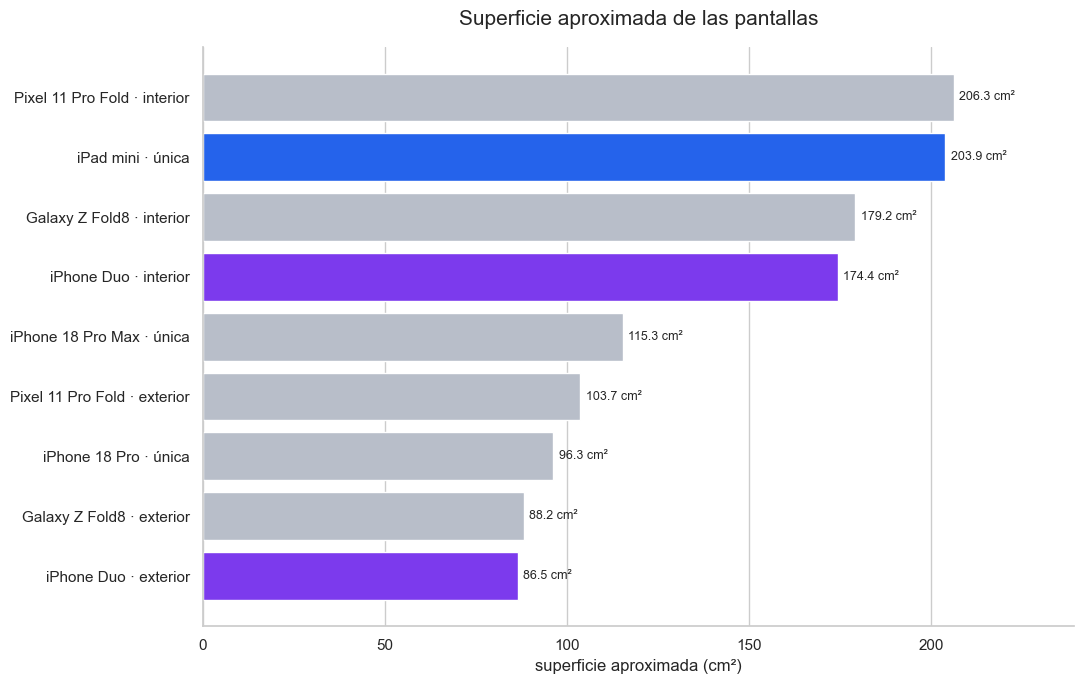

In [11]:
# creo una copia ordenada para preparar el gráfico
pantallas_grafico = df_pantallas.sort_values(
    by="superficie_cm2",
    ascending=True
).copy()

# creo una etiqueta que identifica el modelo y el tipo de pantalla
pantallas_grafico["etiqueta"] = (
    pantallas_grafico["modelo"]
    + " · "
    + pantallas_grafico["tipo_pantalla"]
)

# asigno un color destacado al iphone duo y otro al ipad mini
colores = [
    "#7c3aed" if modelo == "iPhone Duo"
    else "#2563eb" if modelo == "iPad mini"
    else "#b8bec9"
    for modelo in pantallas_grafico["modelo"]
]

# creo el lienzo y represento la superficie de cada pantalla
fig, ax = plt.subplots(figsize=(11, 7))

barras = ax.barh(
    pantallas_grafico["etiqueta"],
    pantallas_grafico["superficie_cm2"],
    color=colores
)

# mantengo únicamente la cuadrícula vertical para facilitar la comparación
ax.grid(axis="y", visible=False)

# añado el valor al final de cada barra para facilitar la lectura
ax.bar_label(
    barras,
    fmt="%.1f cm²",
    padding=4,
    fontsize=9
)

# añado el título y las etiquetas de los ejes
ax.set_title(
    "Superficie aproximada de las pantallas",
    fontsize=15,
    pad=16
)
ax.set_xlabel("superficie aproximada (cm²)")
ax.set_ylabel("")

# elimino las líneas visuales que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# dejo espacio adicional para mostrar las etiquetas de las barras
ax.set_xlim(
    0,
    pantallas_grafico["superficie_cm2"].max() * 1.16
)

# ajusto la distribución de los elementos
plt.tight_layout()

# guardo el gráfico en la carpeta de imágenes del proyecto
archivo_grafico_superficie = ruta_imagenes / "superficie_pantallas.png"
fig.savefig(
    archivo_grafico_superficie,
    dpi=300,
    bbox_inches="tight"
)

# muestro el gráfico dentro del notebook
plt.show()

## 4. Análisis del peso

El tamaño de la pantalla no determina por sí solo la categoría práctica de un dispositivo. El peso influye en su portabilidad, en la comodidad de uso con una mano y en la facilidad para transportarlo diariamente.

Compararé el iPhone Duo con los móviles convencionales, los plegables rivales y el iPad mini. Mantendré el mismo código de color utilizado en el gráfico anterior para conservar la coherencia visual.

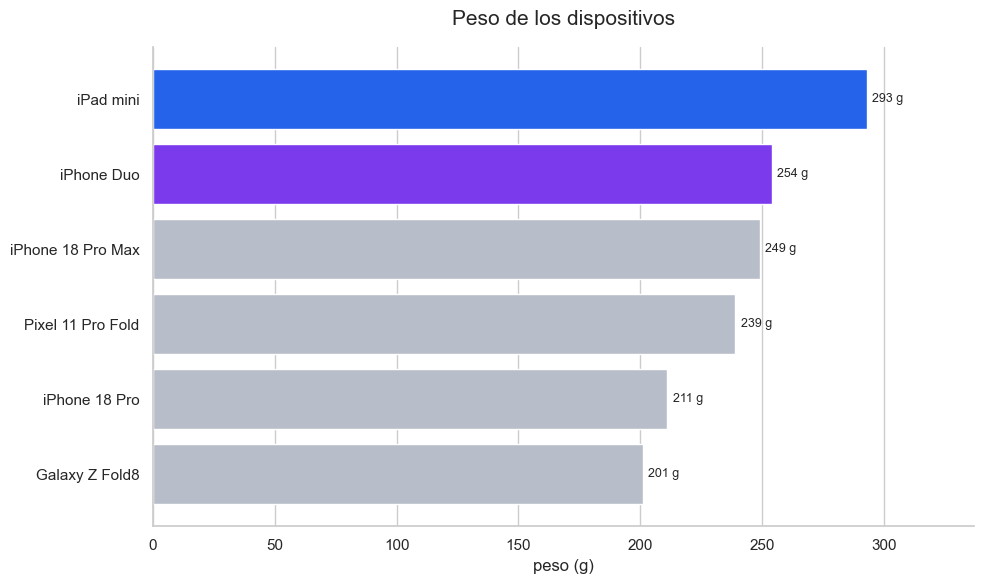

In [12]:
# ordeno los dispositivos de menor a mayor peso
peso_grafico = df_dispositivos.sort_values(
    by="peso_g",
    ascending=True
).copy()

# asigno colores para destacar el iphone duo y el ipad mini
colores_peso = [
    "#7c3aed" if modelo == "iPhone Duo"
    else "#2563eb" if modelo == "iPad mini"
    else "#b8bec9"
    for modelo in peso_grafico["modelo"]
]

# creo el lienzo y represento el peso de cada dispositivo
fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.barh(
    peso_grafico["modelo"],
    peso_grafico["peso_g"],
    color=colores_peso
)

# mantengo únicamente la cuadrícula vertical
ax.grid(axis="y", visible=False)

# añado el peso al final de cada barra
ax.bar_label(
    barras,
    fmt="%.0f g",
    padding=4,
    fontsize=9
)

# añado el título y las etiquetas de los ejes
ax.set_title(
    "Peso de los dispositivos",
    fontsize=15,
    pad=16
)
ax.set_xlabel("peso (g)")
ax.set_ylabel("")

# elimino los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# dejo espacio para mostrar los valores
ax.set_xlim(
    0,
    peso_grafico["peso_g"].max() * 1.15
)

# ajusto la distribución de los elementos
plt.tight_layout()

# guardo el gráfico en la carpeta de imágenes
archivo_grafico_peso = ruta_imagenes / "peso_dispositivos.png"
fig.savefig(
    archivo_grafico_peso,
    dpi=300,
    bbox_inches="tight"
)

# muestro el gráfico dentro del notebook
plt.show()

### 4.1. Diferencia de peso respecto al iPhone Duo

Calcularé cuántos gramos y qué porcentaje separan a cada dispositivo del iPhone Duo.

Los valores negativos identificarán dispositivos más ligeros que el Duo, mientras que los positivos indicarán dispositivos más pesados.

In [13]:
# recupero el peso del iphone duo como valor de referencia
peso_iphone_duo = df_dispositivos.loc[
    df_dispositivos["modelo"] == "iPhone Duo",
    "peso_g"
].iloc[0]

# creo una tabla específica para comparar los pesos
comparacion_peso = df_dispositivos[
    ["modelo", "categoria", "peso_g"]
].copy()

# calculo la diferencia absoluta respecto al iphone duo
comparacion_peso["diferencia_con_duo_g"] = (
    comparacion_peso["peso_g"]
    - peso_iphone_duo
)

# calculo la diferencia porcentual tomando el iphone duo como referencia
comparacion_peso["diferencia_con_duo_pct"] = (
    comparacion_peso["diferencia_con_duo_g"]
    / peso_iphone_duo
    * 100
)

# ordeno los dispositivos desde el más ligero hasta el más pesado
comparacion_peso = comparacion_peso.sort_values(
    by="peso_g",
    ascending=True
).reset_index(drop=True)

# muestro la comparación completa
display(comparacion_peso)

,modelo,categoria,peso_g,diferencia_con_duo_g,diferencia_con_duo_pct
0,Galaxy Z Fold8,plegable,201,-53,-20.87
1,iPhone 18 Pro,móvil,211,-43,-16.93
2,Pixel 11 Pro Fold,plegable,239,-15,-5.91
3,iPhone 18 Pro Max,móvil,249,-5,-1.97
4,iPhone Duo,plegable,254,0,0.00
5,iPad mini,tableta,293,39,15.35


#### Interpretación del peso

El iPhone Duo pesa 254 gramos. Es el segundo dispositivo más pesado de la muestra y solamente queda por debajo del iPad mini, que alcanza los 293 gramos.

Sin embargo, la diferencia entre ambos es de 39 gramos: el iPad mini pesa un 15,35 % más que el Duo. En cambio, el iPhone 18 Pro Max pesa únicamente 5 gramos menos, una diferencia del 1,97 %.

Por tanto, el peso del Duo se aproxima mucho más al de un móvil convencional de gran tamaño que al de la tableta compacta de Apple.

La comparación con otros plegables ofrece un resultado menos favorable. El Pixel 11 Pro Fold pesa 15 gramos menos, mientras que el Galaxy Z Fold8 reduce el peso en 53 gramos, un 20,87 % respecto al Duo.

El Duo combina así una característica propia de un móvil, un peso prácticamente idéntico al del iPhone 18 Pro Max, con una desventaja dentro de su propia categoría: es el plegable más pesado de los tres analizados.

## 5. Análisis del grosor

El grosor permite evaluar dos experiencias diferentes. Cerrado, influye en la portabilidad y en el espacio que ocupa el dispositivo en el bolsillo. Abierto, condiciona la comodidad al sujetarlo y utilizar su pantalla principal.

En los dispositivos no plegables ambos valores son idénticos. En los plegables, la diferencia entre los dos estados permite medir el efecto físico del mecanismo de plegado.

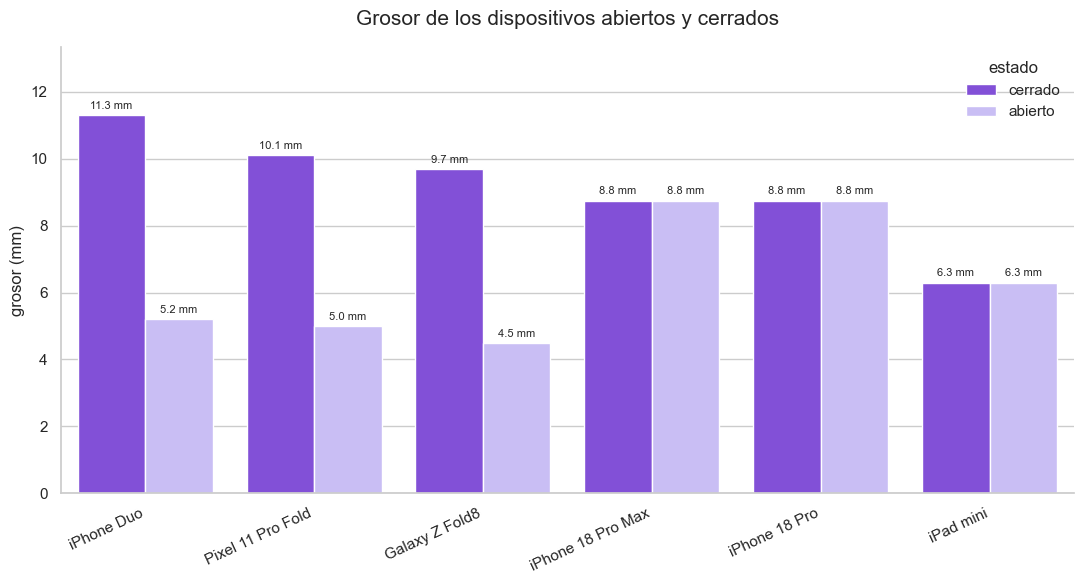

In [14]:
# selecciono las columnas necesarias para comparar el grosor
grosor_grafico = df_dispositivos[
    [
        "modelo",
        "grosor_cerrado_mm",
        "grosor_abierto_mm"
    ]
].copy()

# transformo las columnas de grosor en filas para facilitar el gráfico
grosor_grafico = grosor_grafico.melt(
    id_vars="modelo",
    value_vars=[
        "grosor_cerrado_mm",
        "grosor_abierto_mm"
    ],
    var_name="estado",
    value_name="grosor_mm"
)

# sustituyo los nombres técnicos por etiquetas más legibles
grosor_grafico["estado"] = grosor_grafico["estado"].replace(
    {
        "grosor_cerrado_mm": "cerrado",
        "grosor_abierto_mm": "abierto"
    }
)

# ordeno los modelos según su grosor cerrado
orden_modelos = (
    df_dispositivos
    .sort_values("grosor_cerrado_mm", ascending=False)["modelo"]
    .tolist()
)

# creo el lienzo y comparo el grosor abierto y cerrado
fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=grosor_grafico,
    x="modelo",
    y="grosor_mm",
    hue="estado",
    order=orden_modelos,
    palette={
        "cerrado": "#7c3aed",
        "abierto": "#c4b5fd"
    },
    ax=ax
)

# elimino la cuadrícula vertical para reducir el ruido visual
ax.grid(axis="x", visible=False)

# añado los valores encima de cada barra
for contenedor in ax.containers:
    ax.bar_label(
        contenedor,
        fmt="%.1f mm",
        padding=3,
        fontsize=8
    )

# añado el título y las etiquetas de los ejes
ax.set_title(
    "Grosor de los dispositivos abiertos y cerrados",
    fontsize=15,
    pad=16
)
ax.set_xlabel("")
ax.set_ylabel("grosor (mm)")

# inclino las etiquetas para evitar que se superpongan
plt.xticks(
    rotation=25,
    ha="right"
)

# ajusto la leyenda
ax.legend(
    title="estado",
    frameon=False
)

# elimino los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# dejo espacio para los valores situados sobre las barras
ax.set_ylim(
    0,
    grosor_grafico["grosor_mm"].max() * 1.18
)

# ajusto la distribución de los elementos
plt.tight_layout()

# guardo el gráfico en la carpeta de imágenes
archivo_grafico_grosor = ruta_imagenes / "grosor_abierto_cerrado.png"
fig.savefig(
    archivo_grafico_grosor,
    dpi=300,
    bbox_inches="tight"
)

# muestro el gráfico dentro del notebook
plt.show()

### 5.1. Efecto del plegado sobre el grosor

Calcularé la diferencia entre el grosor cerrado y abierto de los tres plegables. También expresaré el grosor cerrado como múltiplo del grosor abierto.

Una relación próxima a dos sería esperable en un dispositivo formado por dos mitades de grosor similar. Las posibles desviaciones pueden deberse a la bisagra, al espacio entre las partes o a una distribución asimétrica de los componentes.

In [15]:
# selecciono únicamente los dispositivos plegables
comparacion_grosor = df_dispositivos.loc[
    df_dispositivos["categoria"] == "plegable",
    [
        "modelo",
        "grosor_cerrado_mm",
        "grosor_abierto_mm"
    ]
].copy()

# calculo cuánto aumenta el grosor al cerrar cada dispositivo
comparacion_grosor["aumento_al_cerrar_mm"] = (
    comparacion_grosor["grosor_cerrado_mm"]
    - comparacion_grosor["grosor_abierto_mm"]
)

# calculo el aumento porcentual respecto al grosor abierto
comparacion_grosor["aumento_al_cerrar_pct"] = (
    comparacion_grosor["aumento_al_cerrar_mm"]
    / comparacion_grosor["grosor_abierto_mm"]
    * 100
)

# calculo cuántas veces representa el grosor cerrado respecto al abierto
comparacion_grosor["relacion_cerrado_abierto"] = (
    comparacion_grosor["grosor_cerrado_mm"]
    / comparacion_grosor["grosor_abierto_mm"]
)

# ordeno los plegables desde el más grueso hasta el más fino cuando están cerrados
comparacion_grosor = comparacion_grosor.sort_values(
    by="grosor_cerrado_mm",
    ascending=False
).reset_index(drop=True)

# muestro las diferencias calculadas
display(comparacion_grosor)

,modelo,grosor_cerrado_mm,grosor_abierto_mm,aumento_al_cerrar_mm,aumento_al_cerrar_pct,relacion_cerrado_abierto
0,iPhone Duo,11.30,5.20,6.10,117.31,2.17
1,Pixel 11 Pro Fold,10.10,5.00,5.10,102.00,2.02
2,Galaxy Z Fold8,9.70,4.50,5.20,115.56,2.16


#### Interpretación del grosor

El iPhone Duo es el plegable más grueso de la muestra tanto cerrado como abierto.

Cerrado alcanza 11,3 milímetros, frente a los 10,1 milímetros del Pixel 11 Pro Fold y los 9,7 milímetros del Galaxy Z Fold8. Por tanto, el Duo es 1,2 milímetros más grueso que el Pixel y 1,6 milímetros más grueso que el Galaxy.

Abierto, el Duo mide 5,2 milímetros. También supera los 5 milímetros del Pixel y los 4,5 milímetros del Galaxy, aunque las diferencias se reducen en este estado.

Al cerrarse, el grosor del Duo aumenta un 117,31 % y pasa a representar 2,17 veces su grosor abierto. Esta relación es prácticamente idéntica a la del Galaxy Z Fold8, con 2,16 veces, mientras que el Pixel se aproxima más a una duplicación exacta, con 2,02 veces.

Por tanto, el elevado grosor cerrado del Duo no parece proceder únicamente de una penalización excepcional al plegarse. El dispositivo ya es el más grueso de los tres cuando está abierto y mantiene esa posición al cerrarse.

Desde el punto de vista de la portabilidad, los 11,3 milímetros alejan al Duo de los móviles convencionales analizados, ambos con 8,75 milímetros, y lo convierten en el dispositivo más grueso de toda la muestra cuando se transporta.

## 6. Superficie física del dispositivo

Además de la pantalla, calcularé la superficie frontal aproximada que ocupa cada dispositivo mediante la multiplicación de su altura por su anchura.

Esta medida permitirá comparar el espacio que ocupa cerrado, relevante para transportarlo, y abierto, relacionado con su formato de uso. Se trata de una aproximación rectangular que no descuenta las esquinas redondeadas ni tiene en cuenta el volumen de las cámaras.

In [16]:
# calculo la superficie frontal del dispositivo cuando está cerrado
df_dispositivos["superficie_cerrado_cm2"] = (
    df_dispositivos["alto_cerrado_mm"]
    * df_dispositivos["ancho_cerrado_mm"]
    / 100
)

# calculo la superficie frontal del dispositivo cuando está abierto
df_dispositivos["superficie_abierto_cm2"] = (
    df_dispositivos["alto_abierto_mm"]
    * df_dispositivos["ancho_abierto_mm"]
    / 100
)

# calculo cuánto aumenta la superficie frontal al abrir el dispositivo
df_dispositivos["aumento_superficie_cm2"] = (
    df_dispositivos["superficie_abierto_cm2"]
    - df_dispositivos["superficie_cerrado_cm2"]
)

# calculo el aumento porcentual tomando como referencia el estado cerrado
df_dispositivos["aumento_superficie_pct"] = (
    df_dispositivos["aumento_superficie_cm2"]
    / df_dispositivos["superficie_cerrado_cm2"]
    * 100
)

# creo una tabla con las métricas necesarias para la comparación
comparacion_superficie_dispositivo = df_dispositivos[
    [
        "modelo",
        "categoria",
        "superficie_cerrado_cm2",
        "superficie_abierto_cm2",
        "aumento_superficie_cm2",
        "aumento_superficie_pct"
    ]
].copy()

# ordeno los dispositivos según la superficie que ocupan abiertos
comparacion_superficie_dispositivo = (
    comparacion_superficie_dispositivo
    .sort_values(
        by="superficie_abierto_cm2",
        ascending=False
    )
    .reset_index(drop=True)
)

# muestro las superficies calculadas
display(comparacion_superficie_dispositivo)

,modelo,categoria,superficie_cerrado_cm2,superficie_abierto_cm2,aumento_superficie_cm2,aumento_superficie_pct
0,iPad mini,tableta,263.40,263.40,0.00,0.00
1,Pixel 11 Pro Fold,plegable,117.95,233.42,115.47,97.89
2,Galaxy Z Fold8,plegable,101.47,199.97,98.50,97.07
3,iPhone Duo,plegable,99.07,193.90,94.83,95.72
4,iPhone 18 Pro Max,móvil,127.45,127.45,0.00,0.00
5,iPhone 18 Pro,móvil,107.85,107.85,0.00,0.00


#### Interpretación de la superficie física

Cerrado, el iPhone Duo ocupa aproximadamente 99,07 cm² y presenta la menor superficie frontal de toda la muestra. Incluso queda por debajo del iPhone 18 Pro, que alcanza 107,85 cm².

Este resultado no significa que el Duo sea más estrecho: con 84,1 milímetros es más ancho que los dos iPhone convencionales. Su menor superficie se debe principalmente a su altura de solo 117,8 milímetros. Por tanto, cerrado adopta un formato especialmente corto y ancho.

Al abrirse, su superficie frontal aumenta un 95,72 % y alcanza 193,90 cm². Esto supone aproximadamente un 52,1 % más que el iPhone 18 Pro Max y un 79,8 % más que el iPhone 18 Pro.

A pesar de este crecimiento, el Duo continúa por debajo del iPad mini, cuya superficie física alcanza 263,40 cm². El Duo abierto equivale aproximadamente al 73,6 % de la superficie frontal del iPad mini.

También es el plegable más compacto cuando está abierto. El Galaxy Z Fold8 alcanza 199,97 cm² y el Pixel 11 Pro Fold llega hasta 233,42 cm².

Por tanto, el iPhone Duo presenta dos identidades físicas diferenciadas: cerrado ocupa menos superficie frontal que un móvil convencional, aunque es más ancho y grueso; abierto supera ampliamente el formato de un móvil, pero continúa siendo sensiblemente más compacto que el iPad mini.

### 6.1. Aprovechamiento frontal aproximado

Relacionaré la superficie estimada de cada pantalla con la superficie frontal del dispositivo en el estado correspondiente.

Para las pantallas interiores utilizaré las dimensiones del dispositivo abierto. Para las exteriores y las pantallas únicas utilizaré las dimensiones del dispositivo cerrado.

El resultado será una aproximación y no una relación pantalla-cuerpo oficial, ya que emplea rectángulos completos y no descuenta esquinas redondeadas, bisagras, marcos ni otros elementos físicos.

In [17]:
# selecciono las superficies físicas necesarias para relacionarlas con las pantallas
superficies_dispositivos = df_dispositivos[
    [
        "fabricante",
        "modelo",
        "superficie_cerrado_cm2",
        "superficie_abierto_cm2"
    ]
].copy()

# uno las pantallas con las superficies físicas de sus dispositivos
df_aprovechamiento = df_pantallas.merge(
    superficies_dispositivos,
    on=["fabricante", "modelo"],
    how="left",
    validate="many_to_one"
)

# asigno la superficie del dispositivo abierto a las pantallas interiores
# y la superficie cerrada a las pantallas exteriores o únicas
df_aprovechamiento["superficie_dispositivo_cm2"] = np.where(
    df_aprovechamiento["tipo_pantalla"] == "interior",
    df_aprovechamiento["superficie_abierto_cm2"],
    df_aprovechamiento["superficie_cerrado_cm2"]
)

# calculo qué porcentaje del frontal ocupa aproximadamente la pantalla
df_aprovechamiento["aprovechamiento_frontal_pct"] = (
    df_aprovechamiento["superficie_cm2"]
    / df_aprovechamiento["superficie_dispositivo_cm2"]
    * 100
)

# preparo una tabla resumida y la ordeno de mayor a menor aprovechamiento
comparacion_aprovechamiento = (
    df_aprovechamiento[
        [
            "modelo",
            "tipo_pantalla",
            "superficie_cm2",
            "superficie_dispositivo_cm2",
            "aprovechamiento_frontal_pct"
        ]
    ]
    .sort_values(
        by="aprovechamiento_frontal_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

# muestro el aprovechamiento frontal estimado
display(comparacion_aprovechamiento)

,modelo,tipo_pantalla,superficie_cm2,superficie_dispositivo_cm2,aprovechamiento_frontal_pct
0,iPhone 18 Pro Max,única,115.31,127.45,90.47
1,iPhone Duo,interior,174.43,193.90,89.96
2,Galaxy Z Fold8,interior,179.19,199.97,89.61
3,iPhone 18 Pro,única,96.29,107.85,89.28
4,Pixel 11 Pro Fold,interior,206.32,233.42,88.39
5,Pixel 11 Pro Fold,exterior,103.66,117.95,87.88
6,iPhone Duo,exterior,86.52,99.07,87.33
7,Galaxy Z Fold8,exterior,88.19,101.47,86.91
8,iPad mini,única,203.92,263.40,77.42


#### Interpretación del aprovechamiento frontal

La pantalla interior del iPhone Duo ocupa aproximadamente el 89,96 % de la superficie frontal disponible cuando el dispositivo está abierto. Es el segundo valor más alto de toda la muestra y queda únicamente por debajo del iPhone 18 Pro Max, con un 90,47 %.

El iPad mini presenta un aprovechamiento aproximado del 77,42 %, el valor más bajo del conjunto. La diferencia respecto a la pantalla interior del Duo es de 12,54 puntos porcentuales.

Este resultado explica por qué la pantalla interior del Duo alcanza el 85,5 % de la superficie de la pantalla del iPad mini aunque su chasis abierto represente solamente el 73,6 % de la superficie física de la tableta.

La pantalla interior del Duo también supera ligeramente el aprovechamiento estimado del Galaxy Z Fold8, con un 89,61 %, y del Pixel 11 Pro Fold, con un 88,39 %.

En cambio, su pantalla exterior aprovecha aproximadamente el 87,33 % del frontal cerrado. Este resultado queda por debajo de los dos iPhone convencionales y de la pantalla exterior del Pixel, aunque supera ligeramente al Galaxy Z Fold8.

Los datos sugieren que el Duo prioriza la pantalla interior: abierto consigue un aprovechamiento propio de los móviles con marcos reducidos, mientras que cerrado ofrece una pantalla exterior más pequeña y con un aprovechamiento ligeramente inferior.

## 7. Análisis del precio

### 7.1. Precio por superficie de pantalla principal

Para comparar el coste de dispositivos con pantallas de tamaños diferentes, calcularé el precio oficial inicial por cada centímetro cuadrado de pantalla principal.

En los plegables consideraré como principal la pantalla interior. En los móviles convencionales y en el iPad mini utilizaré su pantalla única.

Esta métrica no mide la calidad completa ni el valor real del dispositivo: no incorpora cámaras, procesador, materiales, software o capacidades adicionales. Servirá únicamente para contextualizar cuánto se paga por la superficie visual disponible.

In [18]:
# selecciono la pantalla interior de los plegables
# y la pantalla única de los dispositivos no plegables
pantallas_principales = df_pantallas.loc[
    df_pantallas["tipo_pantalla"].isin(["interior", "única"]),
    [
        "fabricante",
        "modelo",
        "tipo_pantalla",
        "diagonal_pulgadas",
        "superficie_cm2"
    ]
].copy()

# selecciono el precio, el almacenamiento y la categoría de cada dispositivo
datos_economicos = df_dispositivos[
    [
        "fabricante",
        "modelo",
        "categoria",
        "precio_usd",
        "almacenamiento_gb"
    ]
].copy()

# uno cada dispositivo con su pantalla principal
comparacion_precio = datos_economicos.merge(
    pantallas_principales,
    on=["fabricante", "modelo"],
    how="left",
    validate="one_to_one"
)

# calculo el precio por centímetro cuadrado de pantalla principal
comparacion_precio["precio_por_cm2_usd"] = (
    comparacion_precio["precio_usd"]
    / comparacion_precio["superficie_cm2"]
)

# ordeno los dispositivos desde el mayor hasta el menor coste por superficie
comparacion_precio = comparacion_precio.sort_values(
    by="precio_por_cm2_usd",
    ascending=False
).reset_index(drop=True)

# muestro las variables utilizadas en la comparación
display(
    comparacion_precio[
        [
            "modelo",
            "categoria",
            "precio_usd",
            "almacenamiento_gb",
            "diagonal_pulgadas",
            "superficie_cm2",
            "precio_por_cm2_usd"
        ]
    ]
)

,modelo,categoria,precio_usd,almacenamiento_gb,diagonal_pulgadas,superficie_cm2,precio_por_cm2_usd
0,iPhone 18 Pro,móvil,1199.00,256,6.27,96.29,12.45
1,iPhone Duo,plegable,1999.00,256,7.58,174.43,11.46
2,iPhone 18 Pro Max,móvil,1299.00,256,6.86,115.31,11.27
3,Galaxy Z Fold8,plegable,1899.99,256,7.60,179.19,10.60
4,Pixel 11 Pro Fold,plegable,1899.00,256,8.00,206.32,9.20
5,iPad mini,tableta,599.00,128,8.30,203.92,2.94


#### Interpretación del precio por superficie

El iPhone Duo cuesta aproximadamente 11,46 dólares por cada centímetro cuadrado de su pantalla interior. Es el segundo valor más alto de la muestra, únicamente por debajo del iPhone 18 Pro, que alcanza 12,45 dólares por cm².

Dentro de la categoría de plegables, el Duo presenta el coste por superficie más elevado. El Galaxy Z Fold8 se sitúa en 10,60 dólares por cm² y el Pixel 11 Pro Fold baja hasta 9,20 dólares por cm².

Por tanto, el Duo cuesta aproximadamente un 8,1 % más por unidad de superficie que el Galaxy y un 24,6 % más que el Pixel.

La diferencia con el iPad mini es mucho mayor. La tableta ofrece una superficie de pantalla superior por 2,94 dólares por cm². El coste por superficie del Duo es aproximadamente 3,9 veces mayor.

Esta comparación debe interpretarse con cautela. El iPad mini parte de 128 GB, frente a los 256 GB de los demás dispositivos, y no incluye el mecanismo de plegado ni las mismas funciones de telefonía. Además, el precio por superficie no refleja la calidad del panel, el rendimiento, las cámaras o el software.

Aun con estas limitaciones, los datos indican que el precio del Duo responde principalmente a su condición de dispositivo plegable de gama alta y no a una ventaja excepcional en superficie de pantalla.

## 8. Relación entre superficie de pantalla y peso

Compararé la superficie de la pantalla principal con el peso de cada dispositivo. Esta relación permite observar cuánto espacio visual ofrece cada modelo a cambio de la masa que debe transportar el usuario.

Los colores representarán las categorías y el iPhone Duo aparecerá resaltado con un borde para facilitar su localización.

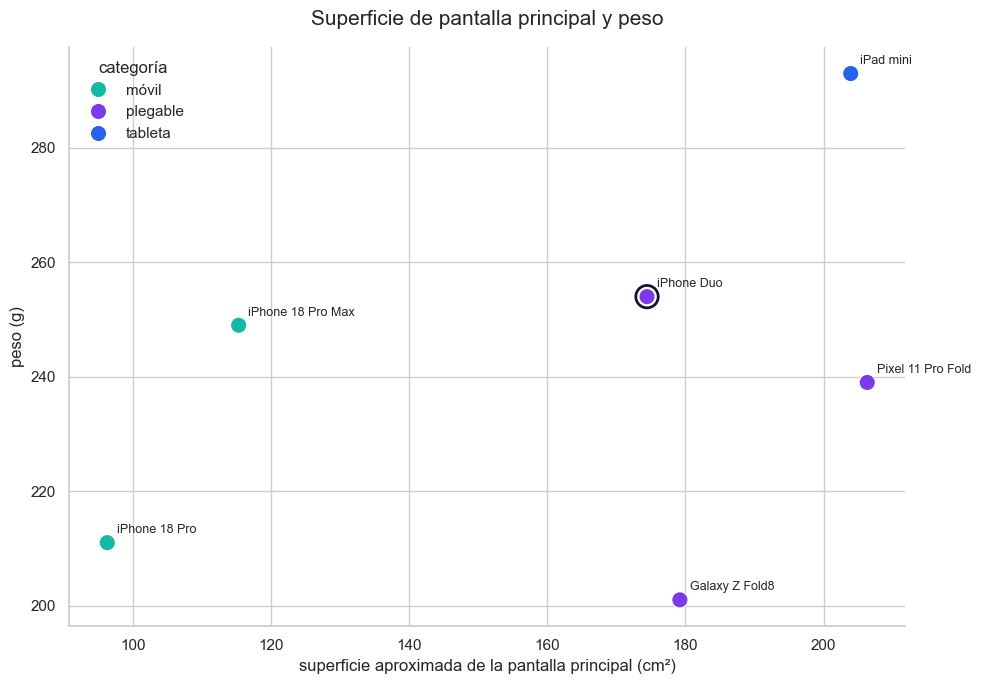

In [19]:
# selecciono las variables necesarias para relacionar pantalla y peso
pantalla_peso = comparacion_precio[
    [
        "modelo",
        "categoria",
        "superficie_cm2"
    ]
].merge(
    df_dispositivos[
        [
            "modelo",
            "peso_g"
        ]
    ],
    on="modelo",
    how="left",
    validate="one_to_one"
)

# defino un color para cada categoría de dispositivo
colores_categorias = {
    "móvil": "#14b8a6",
    "plegable": "#7c3aed",
    "tableta": "#2563eb"
}

# creo el lienzo y represento la relación entre superficie y peso
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=pantalla_peso,
    x="superficie_cm2",
    y="peso_g",
    hue="categoria",
    palette=colores_categorias,
    s=140,
    ax=ax
)

# recupero la fila del iphone duo para resaltarla visualmente
punto_duo = pantalla_peso.loc[
    pantalla_peso["modelo"] == "iPhone Duo"
]

# dibujo un borde adicional alrededor del iphone duo
ax.scatter(
    punto_duo["superficie_cm2"],
    punto_duo["peso_g"],
    s=260,
    facecolors="none",
    edgecolors="#111827",
    linewidths=2
)

# añado el nombre de cada dispositivo junto a su punto
for _, fila in pantalla_peso.iterrows():
    ax.annotate(
        fila["modelo"],
        (
            fila["superficie_cm2"],
            fila["peso_g"]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9
    )

# añado el título y las etiquetas de los ejes
ax.set_title(
    "Superficie de pantalla principal y peso",
    fontsize=15,
    pad=16
)
ax.set_xlabel("superficie aproximada de la pantalla principal (cm²)")
ax.set_ylabel("peso (g)")

# ajusto la leyenda y elimino bordes innecesarios
ax.legend(
    title="categoría",
    frameon=False
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ajusto la distribución de los elementos
plt.tight_layout()

# guardo el gráfico en la carpeta de imágenes
archivo_grafico_pantalla_peso = ruta_imagenes / "superficie_pantalla_peso.png"
fig.savefig(
    archivo_grafico_pantalla_peso,
    dpi=300,
    bbox_inches="tight"
)

# muestro el gráfico dentro del notebook
plt.show()

### 8.1. Superficie de pantalla por cada 100 gramos

Calcularé cuántos centímetros cuadrados de pantalla principal ofrece cada dispositivo por cada 100 gramos de peso.

Un valor mayor indicará que el dispositivo proporciona más superficie visual en relación con su peso. Esta métrica no mide la ergonomía ni la distribución del peso, pero permite comparar la eficiencia física de forma sencilla.

In [20]:
# calculo la superficie de pantalla principal por cada cien gramos
pantalla_peso["superficie_por_100g_cm2"] = (
    pantalla_peso["superficie_cm2"]
    / pantalla_peso["peso_g"]
    * 100
)

# ordeno los dispositivos desde la mayor hasta la menor relación
comparacion_superficie_peso = (
    pantalla_peso[
        [
            "modelo",
            "categoria",
            "superficie_cm2",
            "peso_g",
            "superficie_por_100g_cm2"
        ]
    ]
    .sort_values(
        by="superficie_por_100g_cm2",
        ascending=False
    )
    .reset_index(drop=True)
)

# creo una posición ordinal para facilitar la lectura del resultado
comparacion_superficie_peso.index = (
    comparacion_superficie_peso.index + 1
)
comparacion_superficie_peso.index.name = "posición"

# muestro la clasificación resultante
display(comparacion_superficie_peso)

,modelo,categoria,superficie_cm2,peso_g,superficie_por_100g_cm2
posición,,,,,
1,Galaxy Z Fold8,plegable,179.19,201,89.15
2,Pixel 11 Pro Fold,plegable,206.32,239,86.33
3,iPad mini,tableta,203.92,293,69.60
4,iPhone Duo,plegable,174.43,254,68.67
5,iPhone 18 Pro Max,móvil,115.31,249,46.31
6,iPhone 18 Pro,móvil,96.29,211,45.63


#### Interpretación de la superficie por peso

El iPhone Duo ofrece aproximadamente 68,67 cm² de pantalla principal por cada 100 gramos de peso. Este resultado lo sitúa en la cuarta posición de los seis dispositivos analizados.

Su valor es prácticamente idéntico al del iPad mini, que alcanza 69,60 cm² por cada 100 gramos. La diferencia entre ambos es inferior a un centímetro cuadrado por cada 100 gramos.

En cambio, los plegables rivales presentan una relación considerablemente mejor. El Galaxy Z Fold8 lidera la clasificación con 89,15 cm² por cada 100 gramos, mientras que el Pixel 11 Pro Fold alcanza 86,33 cm².

El Galaxy ofrece aproximadamente un 29,8 % más de superficie por unidad de peso que el Duo, y el Pixel lo supera en torno a un 25,7 %.

Frente a los móviles convencionales, el resultado cambia. El Duo proporciona aproximadamente un 48,3 % más de superficie por cada 100 gramos que el iPhone 18 Pro Max y un 50,5 % más que el iPhone 18 Pro.

Por tanto, la relación entre superficie y peso aproxima nuevamente al iPhone Duo al iPad mini. Sin embargo, dentro de la categoría de plegables, el Duo resulta menos eficiente que sus dos rivales: pesa más y ofrece una pantalla interior de menor superficie.

## 9. Análisis de la relación de aspecto

La relación de aspecto indica cuánto mide el lado largo de una pantalla respecto al lado corto.

Un valor próximo a 1 representa una pantalla casi cuadrada. Los valores más altos corresponden a formatos más alargados, habituales en los teléfonos móviles. Las tabletas y las pantallas interiores de los plegables suelen presentar proporciones más cercanas al cuadrado.

Utilizaré la relación calculada a partir de la resolución, independientemente de la orientación en la que se utilice el dispositivo.

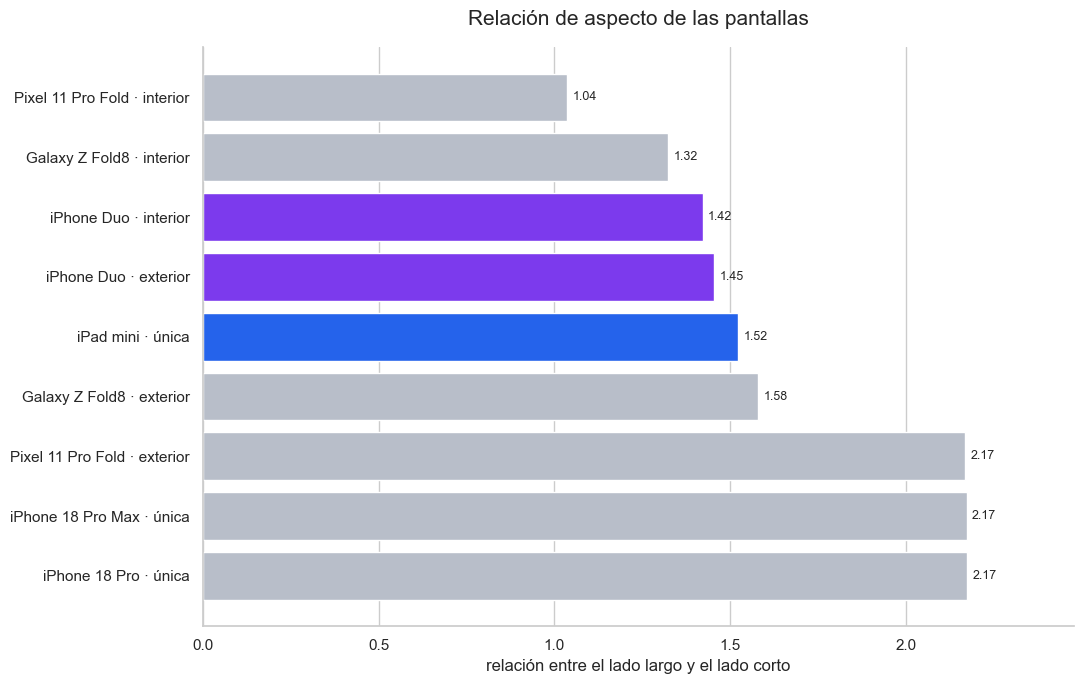

In [21]:
# ordeno las pantallas desde la proporción más cuadrada hasta la más alargada
aspecto_grafico = df_pantallas.sort_values(
    by="relacion_aspecto",
    ascending=False
).copy()

# creo una etiqueta que combina el modelo y el tipo de pantalla
aspecto_grafico["etiqueta"] = (
    aspecto_grafico["modelo"]
    + " · "
    + aspecto_grafico["tipo_pantalla"]
)

# asigno colores para destacar el iphone duo y el ipad mini
colores_aspecto = [
    "#7c3aed" if modelo == "iPhone Duo"
    else "#2563eb" if modelo == "iPad mini"
    else "#b8bec9"
    for modelo in aspecto_grafico["modelo"]
]

# creo el lienzo y represento la relación de aspecto
fig, ax = plt.subplots(figsize=(11, 7))

barras = ax.barh(
    aspecto_grafico["etiqueta"],
    aspecto_grafico["relacion_aspecto"],
    color=colores_aspecto
)

# elimino la cuadrícula horizontal para mejorar la lectura
ax.grid(axis="y", visible=False)

# añado el valor de la relación al final de cada barra
ax.bar_label(
    barras,
    fmt="%.2f",
    padding=4,
    fontsize=9
)

# añado el título y las etiquetas de los ejes
ax.set_title(
    "Relación de aspecto de las pantallas",
    fontsize=15,
    pad=16
)
ax.set_xlabel("relación entre el lado largo y el lado corto")
ax.set_ylabel("")

# elimino los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# dejo espacio adicional para mostrar los valores
ax.set_xlim(
    0,
    aspecto_grafico["relacion_aspecto"].max() * 1.14
)

# ajusto la distribución de los elementos
plt.tight_layout()

# guardo el gráfico en la carpeta de imágenes
archivo_grafico_aspecto = ruta_imagenes / "relacion_aspecto_pantallas.png"
fig.savefig(
    archivo_grafico_aspecto,
    dpi=300,
    bbox_inches="tight"
)

# muestro el gráfico dentro del notebook
plt.show()

#### Interpretación de la relación de aspecto

La pantalla interior del iPhone Duo presenta una relación de aspecto de 1,42. Esto significa que su lado largo mide aproximadamente 1,42 veces su lado corto.

El resultado se encuentra muy cerca del iPad mini, cuya relación es de 1,52. La diferencia entre ambos es de solo 0,10 puntos.

En cambio, las pantallas de los iPhone 18 Pro y 18 Pro Max alcanzan una relación aproximada de 2,17. Son pantallas mucho más alargadas que la pantalla interior del Duo.

Dentro de los plegables, el Galaxy Z Fold8 presenta una relación de 1,32 y el Pixel 11 Pro Fold se aproxima especialmente al cuadrado, con 1,04. El Duo ofrece, por tanto, la pantalla interior más alargada de los tres plegables, aunque continúa muy lejos de las proporciones de un móvil convencional.

La pantalla exterior del Duo también resulta poco habitual. Su relación de 1,45 es más cercana a la del iPad mini que a la de los iPhone convencionales. Sin embargo, su reducida superficie de 86,52 cm² hace que la experiencia no sea equivalente a la de una tableta.

Por su forma, la pantalla interior del Duo debe considerarse más próxima al formato de una tableta compacta que al de un teléfono móvil tradicional.

## 10. Densidad de píxeles

La resolución total no permite comparar directamente la nitidez de pantallas con tamaños diferentes. Para ello calcularé los píxeles por pulgada, conocidos como PPI, mediante la diagonal de la resolución y la diagonal física de la pantalla.

Un valor mayor indica una mayor concentración de píxeles. Esta métrica describe la densidad teórica, pero no recoge otros aspectos de calidad como el brillo, el contraste, la calibración o la tecnología del panel.

In [22]:
# calculo la diagonal de la resolución mediante el teorema de pitágoras
df_pantallas["diagonal_pixeles"] = np.sqrt(
    df_pantallas["resolucion_ancho_px"] ** 2
    + df_pantallas["resolucion_alto_px"] ** 2
)

# calculo la densidad de píxeles por pulgada
df_pantallas["densidad_ppi"] = (
    df_pantallas["diagonal_pixeles"]
    / df_pantallas["diagonal_pulgadas"]
)

# preparo una tabla resumida para comparar la densidad
comparacion_densidad = (
    df_pantallas[
        [
            "modelo",
            "tipo_pantalla",
            "diagonal_pulgadas",
            "resolucion_ancho_px",
            "resolucion_alto_px",
            "densidad_ppi"
        ]
    ]
    .sort_values(
        by="densidad_ppi",
        ascending=False
    )
    .reset_index(drop=True)
)

# muestro la clasificación por densidad de píxeles
display(comparacion_densidad)

,modelo,tipo_pantalla,diagonal_pulgadas,resolucion_ancho_px,resolucion_alto_px,densidad_ppi
0,iPhone Duo,exterior,5.36,1398,2034,460.47
1,iPhone 18 Pro,única,6.27,1206,2622,460.30
2,iPhone 18 Pro Max,única,6.86,1320,2868,460.23
3,iPhone Duo,interior,7.58,1878,2670,430.65
4,Galaxy Z Fold8,exterior,5.50,1248,1972,424.31
5,Galaxy Z Fold8,interior,7.60,1848,2448,403.58
6,Pixel 11 Pro Fold,exterior,6.50,1080,2342,396.77
7,Pixel 11 Pro Fold,interior,8.00,2076,2152,373.77
8,iPad mini,única,8.30,1488,2266,326.61


#### Interpretación de la densidad de píxeles

La pantalla exterior del iPhone Duo alcanza aproximadamente 460,47 píxeles por pulgada, la densidad más alta de la muestra. El resultado es prácticamente idéntico al de los iPhone 18 Pro y 18 Pro Max, ambos situados alrededor de 460 PPI.

La pantalla interior del Duo ofrece aproximadamente 430,65 PPI. Aunque su densidad es inferior a la de la pantalla exterior, continúa por encima de las pantallas interiores de los otros plegables.

El Galaxy Z Fold8 alcanza 403,58 PPI en su pantalla interior, mientras que el Pixel 11 Pro Fold se sitúa en 373,77 PPI. La pantalla interior del Duo presenta aproximadamente un 6,7 % más de densidad que la del Galaxy y un 15,2 % más que la del Pixel.

La diferencia frente al iPad mini es todavía mayor. La tableta alcanza 326,61 PPI, por lo que la pantalla interior del Duo ofrece aproximadamente un 31,9 % más de densidad.

Por tanto, el Duo no sacrifica nitidez para ofrecer una pantalla interior de mayor tamaño. Su densidad se mantiene más próxima a la de un móvil de gama alta que a la de una tableta compacta y supera a los otros plegables analizados.

## 11. Comparación directa del iPhone Duo

### 11.1. El Duo cerrado frente a un móvil convencional

Cuando está cerrado, el iPhone Duo funciona como un teléfono y utiliza su pantalla exterior. Compararé sus características con el promedio del iPhone 18 Pro y el iPhone 18 Pro Max.

Esta comparación resumirá peso, altura, anchura, grosor, superficie física y superficie de pantalla. Los porcentajes positivos indicarán valores superiores a la media de los móviles y los negativos, valores inferiores.

In [23]:
# identifico los modelos clasificados como móviles convencionales
modelos_moviles = df_dispositivos.loc[
    df_dispositivos["categoria"] == "móvil",
    "modelo"
].tolist()

# calculo los valores físicos medios de los móviles convencionales
media_moviles = (
    df_dispositivos.loc[
        df_dispositivos["modelo"].isin(modelos_moviles)
    ]
    .mean(numeric_only=True)
)

# calculo la superficie media de las pantallas de los móviles
superficie_pantalla_media_moviles = df_pantallas.loc[
    df_pantallas["modelo"].isin(modelos_moviles),
    "superficie_cm2"
].mean()

# recupero los datos físicos del iphone duo
datos_duo = df_dispositivos.loc[
    df_dispositivos["modelo"] == "iPhone Duo"
].iloc[0]

# recupero la superficie de la pantalla exterior del iphone duo
superficie_exterior_duo = df_pantallas.loc[
    (df_pantallas["modelo"] == "iPhone Duo")
    & (df_pantallas["tipo_pantalla"] == "exterior"),
    "superficie_cm2"
].iloc[0]

# construyo una tabla con las variables comparables
duo_cerrado_vs_moviles = pd.DataFrame(
    {
        "metrica": [
            "peso (g)",
            "altura cerrada (mm)",
            "anchura cerrada (mm)",
            "grosor cerrado (mm)",
            "superficie física cerrada (cm²)",
            "superficie de pantalla (cm²)"
        ],
        "iphone_duo": [
            datos_duo["peso_g"],
            datos_duo["alto_cerrado_mm"],
            datos_duo["ancho_cerrado_mm"],
            datos_duo["grosor_cerrado_mm"],
            datos_duo["superficie_cerrado_cm2"],
            superficie_exterior_duo
        ],
        "media_moviles": [
            media_moviles["peso_g"],
            media_moviles["alto_cerrado_mm"],
            media_moviles["ancho_cerrado_mm"],
            media_moviles["grosor_cerrado_mm"],
            media_moviles["superficie_cerrado_cm2"],
            superficie_pantalla_media_moviles
        ]
    }
)

# calculo la diferencia porcentual respecto a la media de los móviles
duo_cerrado_vs_moviles["diferencia_pct"] = (
    (
        duo_cerrado_vs_moviles["iphone_duo"]
        - duo_cerrado_vs_moviles["media_moviles"]
    )
    / duo_cerrado_vs_moviles["media_moviles"]
    * 100
)

# muestro la comparación directa
display(duo_cerrado_vs_moviles)

,metrica,iphone_duo,media_moviles,diferencia_pct
0,peso (g),254.00,230.00,10.43
1,altura cerrada (mm),117.80,156.70,-24.82
2,anchura cerrada (mm),84.10,74.95,12.21
3,grosor cerrado (mm),11.30,8.75,29.14
4,superficie física cerrada (cm²),99.07,117.65,-15.79
5,superficie de pantalla (cm²),86.52,105.80,-18.22


#### Interpretación del Duo cerrado

El iPhone Duo pesa un 10,43 % más que el promedio de los dos iPhone convencionales analizados. A pesar de ocupar menos superficie frontal, no ofrece una reducción equivalente de peso.

Su forma también es claramente diferente. El Duo es un 24,82 % más bajo, pero un 12,21 % más ancho que el promedio de los móviles. Como resultado, adopta unas proporciones más cortas y cuadradas.

El grosor representa su principal penalización cuando está cerrado. Sus 11,3 milímetros superan en un 29,14 % el promedio de los iPhone 18 Pro y Pro Max.

La superficie física cerrada es un 15,79 % menor que la media de los móviles, mientras que la superficie de su pantalla exterior es un 18,22 % inferior.

Por tanto, cerrado conserva la funcionalidad de un teléfono y ocupa menos superficie frontal, pero no reproduce la experiencia física de un móvil convencional. Es más corto, más ancho, considerablemente más grueso y algo más pesado, además de ofrecer una pantalla exterior más pequeña.

### 11.2. El Duo abierto frente al iPad mini

Cuando está abierto, el iPhone Duo ofrece su pantalla interior y adopta un formato próximo al de una tableta compacta.

Compararé directamente ambos dispositivos mediante su peso, dimensiones, superficie física, superficie de pantalla, relación de aspecto y densidad de píxeles.

In [24]:
# recupero los datos físicos del ipad mini
datos_ipad_mini = df_dispositivos.loc[
    df_dispositivos["modelo"] == "iPad mini"
].iloc[0]

# recupero los datos de la pantalla interior del iphone duo
pantalla_interior_duo = df_pantallas.loc[
    (df_pantallas["modelo"] == "iPhone Duo")
    & (df_pantallas["tipo_pantalla"] == "interior")
].iloc[0]

# recupero los datos de la pantalla del ipad mini
pantalla_ipad_mini = df_pantallas.loc[
    df_pantallas["modelo"] == "iPad mini"
].iloc[0]

# construyo una tabla con las variables comparables
duo_abierto_vs_ipad = pd.DataFrame(
    {
        "metrica": [
            "peso (g)",
            "altura (mm)",
            "anchura (mm)",
            "grosor (mm)",
            "superficie física (cm²)",
            "superficie de pantalla (cm²)",
            "relación de aspecto",
            "densidad (ppi)"
        ],
        "iphone_duo": [
            datos_duo["peso_g"],
            datos_duo["alto_abierto_mm"],
            datos_duo["ancho_abierto_mm"],
            datos_duo["grosor_abierto_mm"],
            datos_duo["superficie_abierto_cm2"],
            pantalla_interior_duo["superficie_cm2"],
            pantalla_interior_duo["relacion_aspecto"],
            pantalla_interior_duo["densidad_ppi"]
        ],
        "ipad_mini": [
            datos_ipad_mini["peso_g"],
            datos_ipad_mini["alto_abierto_mm"],
            datos_ipad_mini["ancho_abierto_mm"],
            datos_ipad_mini["grosor_abierto_mm"],
            datos_ipad_mini["superficie_abierto_cm2"],
            pantalla_ipad_mini["superficie_cm2"],
            pantalla_ipad_mini["relacion_aspecto"],
            pantalla_ipad_mini["densidad_ppi"]
        ]
    }
)

# calculo la diferencia porcentual tomando el ipad mini como referencia
duo_abierto_vs_ipad["diferencia_pct"] = (
    (
        duo_abierto_vs_ipad["iphone_duo"]
        - duo_abierto_vs_ipad["ipad_mini"]
    )
    / duo_abierto_vs_ipad["ipad_mini"]
    * 100
)

# muestro la comparación directa
display(duo_abierto_vs_ipad)

,metrica,iphone_duo,ipad_mini,diferencia_pct
0,peso (g),254.00,293.00,-13.31
1,altura (mm),117.80,195.40,-39.71
2,anchura (mm),164.60,134.80,22.11
3,grosor (mm),5.20,6.30,-17.46
4,superficie física (cm²),193.90,263.40,-26.39
5,superficie de pantalla (cm²),174.43,203.92,-14.46
6,relación de aspecto,1.42,1.52,-6.64
7,densidad (ppi),430.65,326.61,31.85


#### Interpretación del Duo abierto

El iPhone Duo pesa un 13,31 % menos que el iPad mini y es un 17,46 % más delgado cuando está abierto. Estas diferencias favorecen su uso como dispositivo portátil y reflejan su origen como teléfono plegable.

Las proporciones físicas son muy distintas. El Duo es un 39,71 % más bajo que el iPad mini, pero un 22,11 % más ancho. Por ello adopta un formato horizontal, bajo y ancho, en lugar de reproducir la silueta tradicional de la tableta de Apple.

Su superficie física total es un 26,39 % menor que la del iPad mini. Sin embargo, la diferencia entre sus pantallas se reduce al 14,46 %, lo que confirma el mejor aprovechamiento frontal del Duo.

La relación de aspecto de la pantalla interior solo difiere un 6,64 % respecto a la del iPad mini. Por tanto, ambas pantallas presentan formas relativamente próximas, aunque la del Duo es algo más cuadrada.

La densidad de píxeles marca una diferencia clara a favor del Duo. Sus 430,65 PPI superan en un 31,85 % los 326,61 PPI del iPad mini y lo acercan a la nitidez característica de un teléfono de gama alta.

El Duo abierto no es un iPad mini plegado por la mitad: es considerablemente más bajo, ancho y compacto. Sin embargo, sí reproduce buena parte de su experiencia visual, al ofrecer el 85,5 % de su superficie de pantalla con una relación de aspecto similar, menor peso y mayor densidad.

## 12. Almacenamiento de los datos procesados

Guardaré en `data/processed` las tablas resultantes del análisis. A diferencia de los archivos originales, estas versiones incluyen variables calculadas como la superficie física, la relación de aspecto, la superficie de pantalla y la densidad de píxeles.

También guardaré las dos comparaciones directas utilizadas para responder la pregunta principal.

In [25]:
# creo la carpeta de datos procesados si todavía no existe
ruta_datos_processed.mkdir(
    parents=True,
    exist_ok=True
)

# construyo las rutas de los archivos procesados
archivo_dispositivos_processed = (
    ruta_datos_processed / "dispositivos_processed.csv"
)
archivo_pantallas_processed = (
    ruta_datos_processed / "pantallas_processed.csv"
)
archivo_duo_cerrado_moviles = (
    ruta_datos_processed / "duo_cerrado_vs_moviles.csv"
)
archivo_duo_abierto_ipad = (
    ruta_datos_processed / "duo_abierto_vs_ipad.csv"
)

# guardo la tabla de dispositivos con las nuevas variables
df_dispositivos.to_csv(
    archivo_dispositivos_processed,
    index=False,
    encoding="utf-8"
)

# guardo la tabla de pantallas con las nuevas variables
df_pantallas.to_csv(
    archivo_pantallas_processed,
    index=False,
    encoding="utf-8"
)

# guardo las comparaciones principales del análisis
duo_cerrado_vs_moviles.to_csv(
    archivo_duo_cerrado_moviles,
    index=False,
    encoding="utf-8"
)

duo_abierto_vs_ipad.to_csv(
    archivo_duo_abierto_ipad,
    index=False,
    encoding="utf-8"
)

# compruebo que todos los archivos se han creado correctamente
archivos_procesados = [
    archivo_dispositivos_processed,
    archivo_pantallas_processed,
    archivo_duo_cerrado_moviles,
    archivo_duo_abierto_ipad
]

for archivo in archivos_procesados:
    print(f"{archivo.name}: {archivo.exists()}")

dispositivos_processed.csv: True
pantallas_processed.csv: True
duo_cerrado_vs_moviles.csv: True
duo_abierto_vs_ipad.csv: True


## 13. Conclusiones

### ¿Es el iPhone Duo un móvil o un iPad mini plegable?

Los resultados describen al iPhone Duo como un dispositivo híbrido, aunque su punto de partida sigue siendo el de un teléfono móvil plegable.

Cerrado, ocupa un 15,79 % menos de superficie frontal que el promedio del iPhone 18 Pro y el iPhone 18 Pro Max. Sin embargo, es un 24,82 % más bajo, un 12,21 % más ancho y un 29,14 % más grueso. También pesa un 10,43 % más y su pantalla exterior ofrece un 18,22 % menos de superficie.

Por tanto, el Duo puede funcionar como un móvil cerrado, pero su formato no reproduce las proporciones ni la comodidad física de un teléfono convencional.

Abierto, su identidad cambia. La pantalla interior alcanza 174,43 cm², aproximadamente el 85,5 % de la superficie del iPad mini. Además, su relación de aspecto de 1,42 está mucho más cerca del 1,52 de la tableta que del 2,17 de los iPhone tradicionales.

El Duo consigue esta experiencia visual con un cuerpo un 26,39 % menor y un peso un 13,31 % inferior al del iPad mini. Su pantalla también ofrece una densidad un 31,85 % superior.

Sin embargo, no puede considerarse literalmente un iPad mini plegable. Su pantalla continúa siendo un 14,46 % menor, su cuerpo es un 39,71 % más bajo y su orientación resulta mucho más ancha. Tampoco reproduce necesariamente las funciones, el sistema operativo o la experiencia de productividad de un iPad.

Dentro de su propia categoría, el Duo tampoco lidera todas las métricas. Es el plegable más pesado y grueso de los tres analizados, ofrece la pantalla interior de menor superficie y presenta el coste más alto por centímetro cuadrado entre los plegables.

### Respuesta final

El iPhone Duo es principalmente un móvil plegable cuando está cerrado, pero su pantalla interior ofrece una experiencia visual más cercana a una tableta compacta que a un teléfono convencional.

No es un iPad mini que pueda doblarse, sino un iPhone que, al abrirse, entrega gran parte de la superficie y las proporciones de un iPad mini en un cuerpo más compacto, ligero y denso.

Su principal atractivo está en esa dualidad. Su principal coste es que, para conseguirla, resulta más grueso y pesado que sus rivales plegables y exige pagar una prima considerable.